<a href="https://colab.research.google.com/github/malishkapatil/DSPY_Lab_202526/blob/main/DSPY_Exp04_2402614.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment No : 04

##**Aim :**
Learn use of maplotlib library as visualisation tool in data science pipeline to create contour plots, histograms and box plots.

## Performance :

[Students need to execute each and every cell in this section and note the output of the same. Once done they have to answer Questions mentioned in review section]


### Density and Contour plots
Sometimes it is useful to display three-dimensional data in two dimensions using contours or color-coded regions.

There are three Matplotlib functions that can be helpful for this task: ``plt.contour`` for contour plots, ``plt.contourf`` for filled contour plots, and ``plt.imshow`` for showing images.

We will see examples of this type of plot in section below

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
import numpy as np

In [ ]:
# A 3D function to plot

def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

A contour plot can be created with the ``plt.contour`` function.
It takes three arguments: a grid of *x* values, a grid of *y* values, and a grid of *z* values.

The *x* and *y* values represent positions on the plot, and the *z* values will be represented by the contour levels.

Perhaps the most straightforward way to prepare such data is to use the ``np.meshgrid`` function, which builds two-dimensional grids from one-dimensional arrays:

In [ ]:
# x is set of 50 values between 0 and 5
# x is set of 40 values between 0 and 5

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)
print(Z)

[[-0.83907153 -0.83470697 -0.8216586  ...  0.8956708   0.68617261
   0.41940746]
 [-0.83907153 -0.8275558  -0.80744041 ...  0.93467448  0.77467433
   0.55894214]
 [-0.83907153 -0.820263   -0.79266951 ...  0.98503397  0.88847607
   0.73757604]
 ...
 [-0.83907153 -0.48696962 -0.02692065 ...  0.98525345  0.79584263
   0.46799565]
 [-0.83907153 -0.47558005 -0.00130271 ...  0.93488414  0.6993547
   0.37933079]
 [-0.83907153 -0.46410908  0.02431613 ...  0.89579384  0.65690314
   0.40107702]]


Now let's look at this with a standard line-only contour plot:

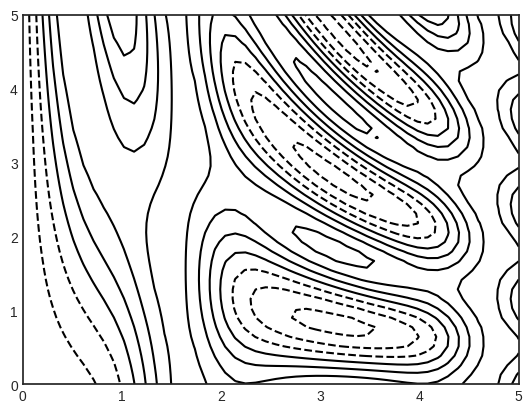

In [ ]:
plt.contour(X, Y, Z, colors='black');

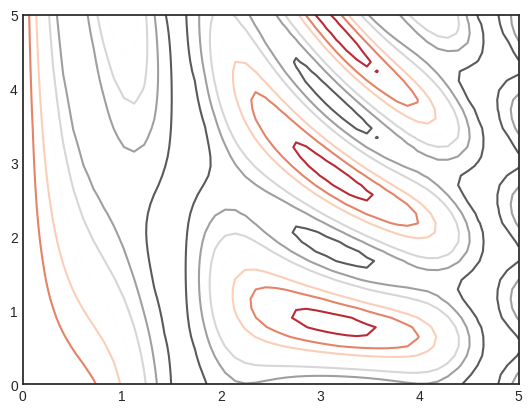

In [ ]:
plt.contour(X, Y, Z, cmap='RdGy');

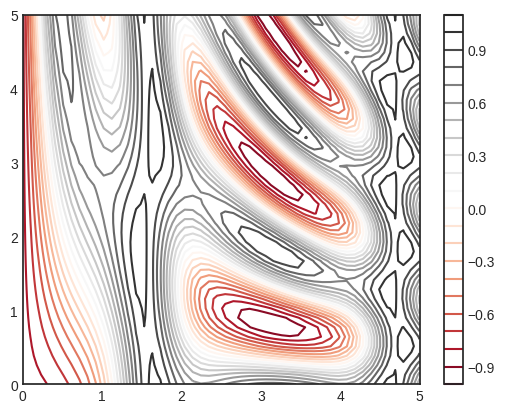

In [ ]:
plt.contour(X, Y, Z, 20, cmap='RdGy');
plt.colorbar();

# Answer Following Questions :
####**1. Explain what are the changes you observe in contour plots above 3 code cells ?**

###ans:

`a. plt.contour(X, Y, Z, colors='black'):- `
In this plot, the contour lines are drawn using a **single color (black).** The function automatically selects a default number of contour levels based on the data. Since no colormap is specified, the contour lines only represent **lines of constant Z values** without any color variation. This type of plot emphasizes the **shape and pattern of the contours**, but it does not visually represent the magnitude of the values.

`b. plt.contour(X, Y, Z, cmap='RdGy'):-`
In this case, a **colormap** (RdGy) is applied to the contour lines. Instead of a single color, the contour lines are colored according to their corresponding **Z values**. The colormap helps distinguish between different contour levels by assigning different colors. However, the number of contour levels is still **automatically determined by Matplotlib**, and there is no color scale displayed.

`c. plt.contour(X, Y, Z, 20, cmap='RdGy'); plt.colorbar():-`Here, the contour function is given an additional parameter 20, which specifies the number of contour levels to be drawn. This produces **more detailed and closely spaced contour lines,** giving a clearer representation of variations in the data. The `RdGy` colormap is again used to represent different values with different colors. Additionally, plt.colorbar() adds a color scale beside the plot, which indicates the relationship between the colors and the corresponding Z values.

####**2. What is size of X, Y and Z  respectively ?**
###ans:

In contour plotting, X and Y represent the coordinate grid, and Z represents the function values evaluated at those coordinates. For the plt.contour(X, Y, Z) function to work correctly:


*   X, Y, and Z must have the same dimensions.
*   Each element Zij corresponds to the function value at the coordinate point (Xij,Yij).

If the grid is generated over the interval 0 to 5 with 50 points in each direction (a common setup), then:

▪ X size: 50×50 50×50

▪ Y size: 50×50 50×50

▪ Z size: 50×50 50×50

General rule if:-


*   X has `m` points.
*   Y has `n` points.

After using meshgrid:

X size = n × m

Y size = n × m

Z size = n × m

Thus, X, Y, and Z all have identical dimensions so that each grid point corresponds to a specific function value used for drawing contour lines.


####**3.How does colorbar() method help in contour plot.**

###ans:

The `colorbar()` method is used to add a color scale (legend) to the contour plot. It shows the relationship between the colors used in the plot and the corresponding numerical values of the variable Z.

▶  In contour plots with a colormap, different colors represent different ranges of data values.

▶  The colorbar displays these values along a scale, allowing the viewer to understand what each color represents.

▶ it improves the interpretation of the plot by indicating the magnitude and variation of the data.










### Creating Smoother Contour Plots
One potential issue with this plot is that it is a bit "splotchy." That is, the color steps are discrete rather than continuous, which is not always what is desired.

This could be remedied by setting the number of contours to a very high number, but this results in a rather inefficient plot: Matplotlib must render a new polygon for each step in the level.
A better way to handle this is to use the ``plt.imshow()`` function, which interprets a two-dimensional grid of data as an image.

The following code shows how to perform this:

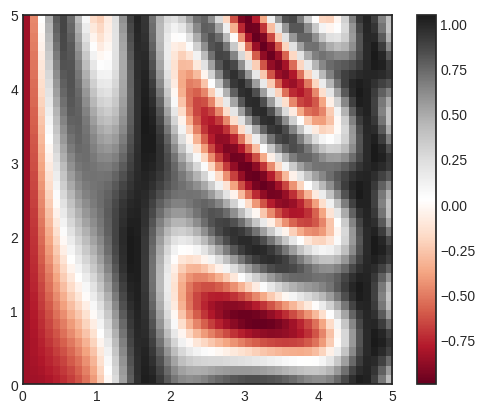

In [ ]:
plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower', cmap='RdGy')
plt.colorbar()
plt.gca().set_aspect('equal')  # Another correct way to set aspect ratio  # Get the current axes(gce)

#### Things to remember while using ``imshow()``:

`plt.imshow() `: doesn't accept an x and y grid, so you must manually specify the extent [xmin, xmax, ymin, ymax] of the image on the plot.

`plt.imshow() `: by default follows the standard image array definition where the origin is in the upper left, not in the lower left as in most contour plots. To match Cartesian coordinates, set origin='lower'.

`plt.imshow() `: will automatically adjust the axis aspect ratio to match the input data; this can be changed by setting, for example,`plt.axis('image')` or `plt.gca().set_aspect('equal') `to make x and y units match.

You can specify a colormap using cmap and add a colorbar to show the mapping between colors and values.

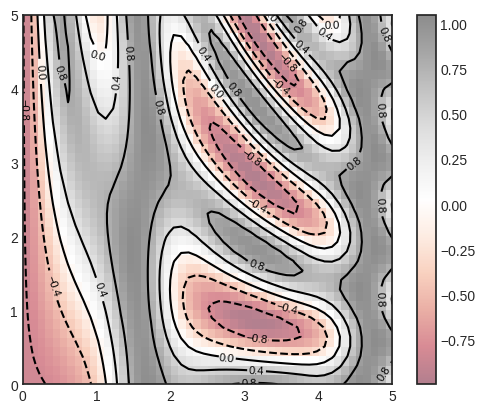

In [ ]:
contours = plt.contour(X, Y, Z, 5, colors='black')
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[0, 5, 0, 5], origin='lower',
           cmap='RdGy', alpha=0.5)
plt.colorbar();

### Answer os the following questions:
####**1. What does the alpha parameter do?**
###ans:

-The alpha parameter controls the transparency of plotted elements.

-It can take a value between 0 and 1:

- alpha = 0 → fully transparent (invisible)

- alpha = 1 → fully opaque (default)

-Useful when overlaying multiple plots (e.g., a contour plot on top of imshow) so that underlying plots remain visible.

* Example:



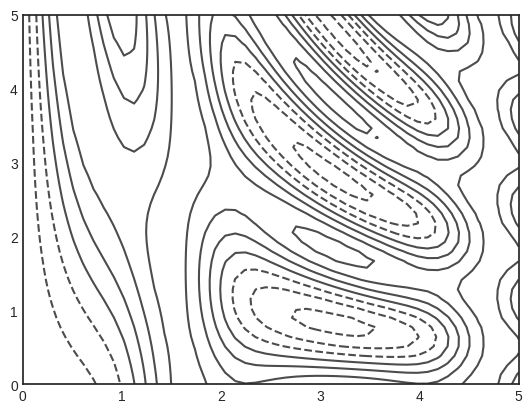

In [ ]:
plt.contour(X, Y, Z, colors='black', alpha=0.7)  # semi-transparent lines

####**2. What does the clabel method do?**
###ans:
clabel is used with contour plots to add labels on contour lines.

It displays the numeric values of the contour levels directly on the plot.

This helps in reading exact values without referring to a separate colorbar.

* Example:

<a list of 31 text.Text objects>

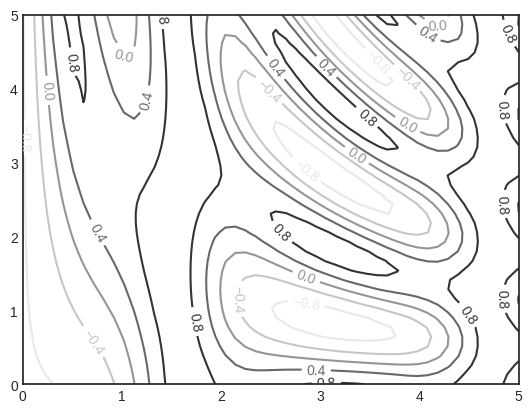

In [ ]:
CS = plt.contour(X, Y, Z, 5)
plt.clabel(CS, inline=True, fontsize=10)  # adds contour labels on lines

####**3. Changing parameter 4 in contour from 3 to 5. Explain what change you see in the plot.**

###ans:

-In your previous code, the contour function had a parameter like this:


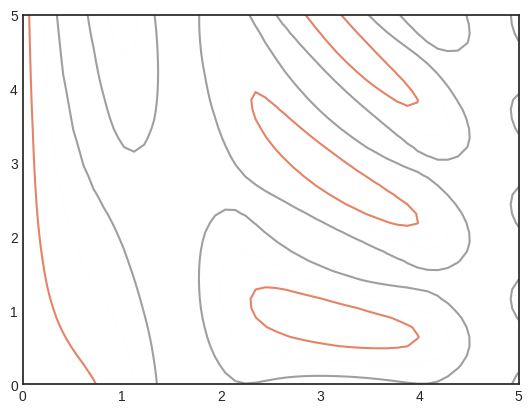

In [ ]:
plt.contour(X, Y, Z, 3, cmap='RdGy')

- Here, `3 specifies` the number of contour levels.

- If we change it to 5:

<a list of 31 text.Text objects>

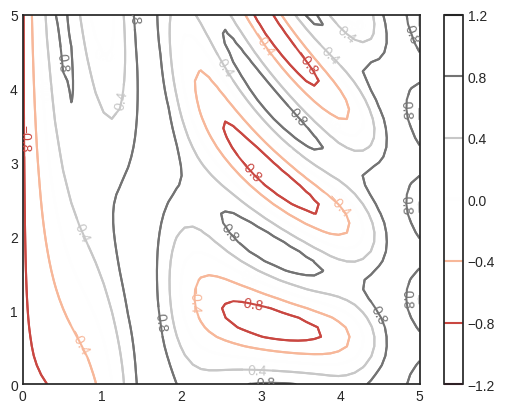

In [ ]:
plt.contour(X, Y, Z, 5, cmap='RdGy')
plt.colorbar()
plt.clabel(plt.contour(X, Y, Z, 5, cmap='RdGy'), inline=True)

Effect of the change:

▶ More contour lines appear (from 3 to 5), giving a finer resolution of Z values.

▶ The plot becomes more detailed, showing smaller variations in the data.

▶ With clabel, all 5 levels are labeled, so you can read exact Z values at each contour.

### Histogram, Binning Plots

A histogram is a graphical representation of a grouped frequency distribution with continuous classes. It is an area diagram and can be defined as a set of rectangles with bases along with the intervals between class boundaries and with areas proportional to frequencies in the corresponding classes. In such representations, all the rectangles are adjacent since the base covers the intervals between class boundaries. The heights of rectangles are proportional to corresponding frequencies of similar classes and for different classes, the heights will be proportional to corresponding frequency densities.

In other words, a histogram is a diagram involving rectangles whose area is proportional to the frequency of a variable and width is equal to the class interval.

The histogram graph is used under certain conditions. They are:



*   The data should be numerical.
*   A histogram is used to check the shape of the data distribution.
*   Used to check whether the process changes from one period to another.
*   Used to determine whether the output is different when it involves two or more processes.
*   Used to analyse whether the given process meets the customer requirements.



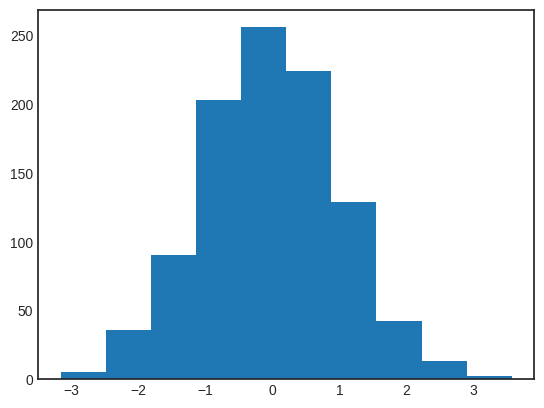

In [ ]:
# How to plot histogram
data = np.random.randn(1000)
plt.hist(data);

The ``hist()`` function has many options to tune both the calculation and the display;
here's an example of a more customized histogram:

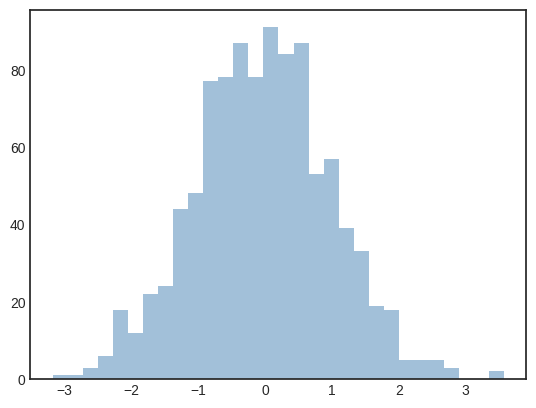

In [ ]:
plt.hist(data, bins=30, alpha=0.5, histtype='stepfilled', color='steelblue', edgecolor='none');

The ``plt.hist`` docstring has more information on other customization options available.
I find this combination of ``histtype='stepfilled'`` along with some transparency ``alpha`` to be very useful when comparing histograms of several distributions:

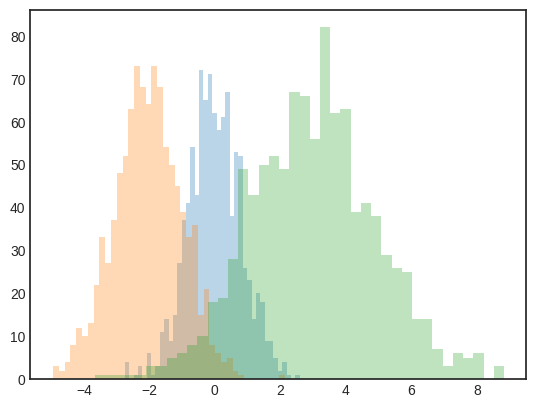

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

If you would like to simply compute the histogram (that is, count the number of points in a given bin) and not display it, the ``np.histogram()`` function is available:

In [ ]:
#Only storing histogram bin frequencies without ploting it
counts, bin_edges = np.histogram(data, bins=5)
print(counts,bin_edges)

[ 41 293 480 171  15] [-3.16415638 -1.81724244 -0.47032849  0.87658545  2.2234994   3.57041334]


### ``plt.hist2d``: Two-dimensional histogram

One straightforward way to plot a two-dimensional histogram is to use Matplotlib's ``plt.hist2d`` function:

In [ ]:
# Create 2 Variable normally distributed data sets with 10000
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

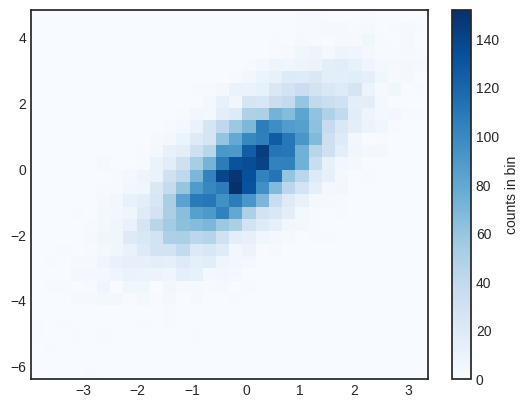

In [ ]:
#Using 2d Histogram plot
plt.hist2d(x, y, bins=30, cmap='Blues')
cb = plt.colorbar()
cb.set_label('counts in bin')

Just as with ``plt.hist``, ``plt.hist2d`` has a number of extra options to fine-tune the plot and the binning, which are nicely outlined in the function docstring.
Further, just as ``plt.hist`` has a counterpart in ``np.histogram``, ``plt.hist2d`` has a counterpart in ``np.histogram2d``, which can be used as follows:

In [ ]:
counts, xedges, yedges = np.histogram2d(x, y, bins=30)

### ``plt.hexbin``: Hexagonal binnings

The two-dimensional histogram creates a tesselation of squares across the axes.
Another natural shape for such a tesselation is the regular hexagon.
For this purpose, Matplotlib provides the ``plt.hexbin`` routine, which will represents a two-dimensional dataset binned within a grid of hexagons:

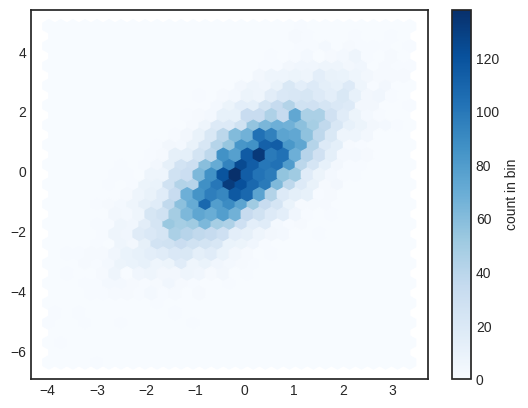

In [ ]:
plt.hexbin(x, y, gridsize=30, cmap='Blues')
cb = plt.colorbar(label='count in bin')

###**Questions:**

####**1.What is role of bins parameter in histogram plot?**
###ans:
-The bins parameter in a histogram determines the number of intervals into which the range of the data is divided.

-Each bin counts how many data points fall within its range.

-The choice of bins affects the visual representation of the data distribution:

  * Few bins → coarse histogram, less detail, only general trends visible.

* Many bins → fine histogram, more detailed, but may appear noisy if excessive.

-Proper selection of bins is crucial to accurately interpret the underlying distribution of data.
####**2.Create a set of 10000 uniform random samples and store it in variable named *norm_data*. Draw histograms of *norm_data* with following bin counts 5, 50, 500, 5000.**
###ans:


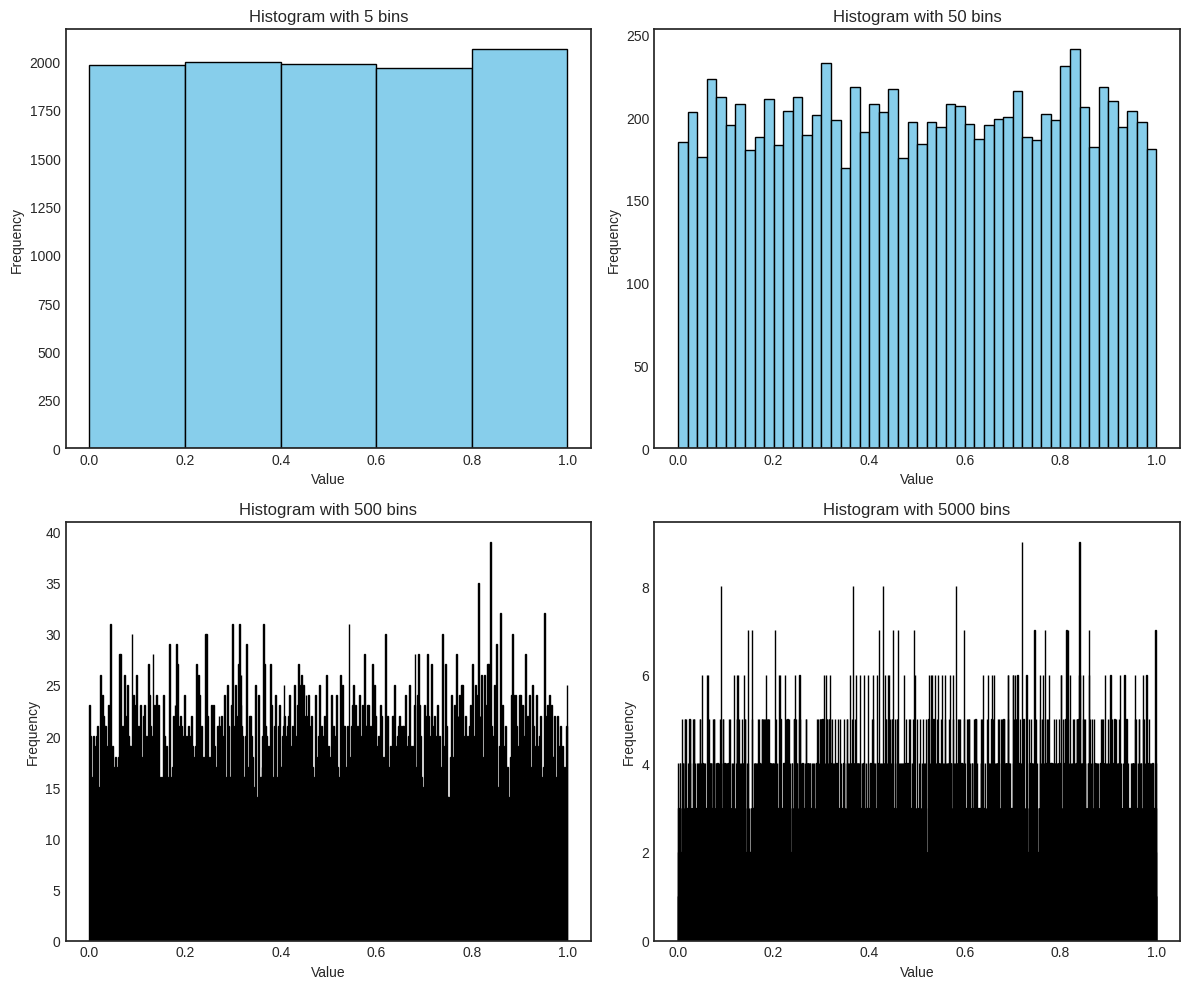

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create 10000 uniform random samples
norm_data = np.random.uniform(low=0, high=1, size=10000)

# Define bin counts
bin_counts = [5, 50, 500, 5000]

# Plot histograms for different bin counts
plt.figure(figsize=(12, 10))

for i, bins in enumerate(bin_counts, 1):
    plt.subplot(2, 2, i)
    plt.hist(norm_data, bins=bins, color='skyblue', edgecolor='black')
    plt.title(f'Histogram with {bins} bins')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

####**3. Explain your observations in text box of above step.**
###ans:

* 5 bins:

  Very coarse.

  Only general shape of the distribution is visible.

  Many details are lost.

* 50 bins:

  Shows a clearer uniform shape.

  Good balance between detail and readability.

* 500 bins:

  Histogram becomes very detailed.

  Individual variations and small fluctuations in the data are visible.

  Bars start looking thin.

* 5000 bins:

  Almost each bar represents a single data point.

  Histogram looks noisy and spiky, losing its smooth distribution shape.

  Not very informative visually.


### Ploting from a CSV File

Saving california_cities.csv to california_cities.csv


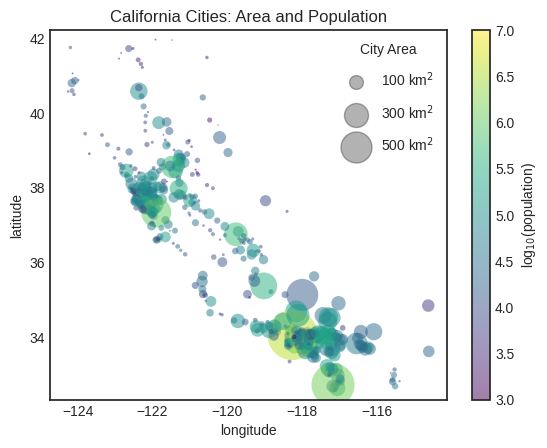

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# خطوة 1: (ONLY if using Google Colab) upload file
# Comment this if you're using Jupyter/VS Code
from google.colab import files
files.upload()

# خطوة 2: read file (no path needed)
cities = pd.read_csv('california_cities.csv')

# Extract data
lat = cities['latd']
lon = cities['longd']
population = cities['population_total']
area = cities['area_total_km2']

# Scatter plot
plt.scatter(lon, lat,
            c=np.log10(population),
            cmap='viridis',
            s=area,
            linewidth=0,
            alpha=0.5)

plt.axis('equal')
plt.xlabel('longitude')
plt.ylabel('latitude')

# Colorbar
plt.colorbar(label='log$_{10}$(population)')
plt.clim(3, 7)

# Legend for area
for a in [100, 300, 500]:
    plt.scatter([], [], c='k', alpha=0.3, s=a,
                label=str(a) + ' km$^2$')

plt.legend(scatterpoints=1, frameon=False,
           labelspacing=1, title='City Area')

plt.title('California Cities: Area and Population')
plt.show()

### Multiple Subplots
Sometimes it is helpful to compare different views of data side by side. Matplotlib has the concept of *subplots* : groups of smaller axes that can exist together within a single figure.

These subplots might be insets, grids of plots, or other more complicated layouts.

In [ ]:
plt.style.use('seaborn-v0_8-white')
import numpy as np

### ``plt.axes``: Subplots by Hand (Coding)

The most basic method of creating an axes is to use the ``plt.axes`` function. By default this creates a standard axes object that fills the entire figure.

``plt.axes`` also takes an optional argument that is a list of four numbers in the figure coordinate system. These numbers represent
``[left, bottom, width, height]`` in the figure coordinate system, which ranges from 0 at the bottom left of the figure to 1 at the top right of the figure.

For example, we might create an inset axes at the top-right corner of another axes by setting the *x* and *y* position to 0.65 (that is, starting at 65% of the width and 65% of the height of the figure) and the *x* and *y* extents to 0.2 (that is, the size of the axes is 20% of the width and 20% of the height of the figure):

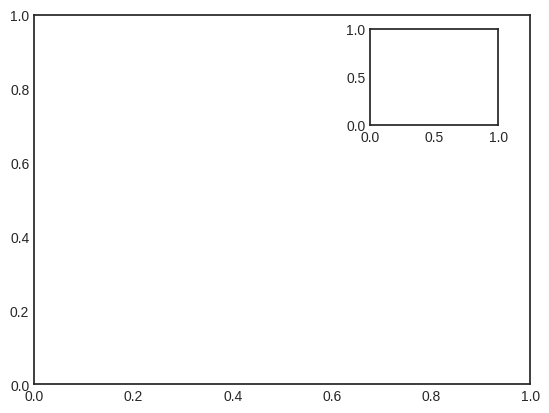

In [ ]:
ax1 = plt.axes()  # standard axes
ax2 = plt.axes([0.650, 0.650, 0.2, 0.2]) #inset axes

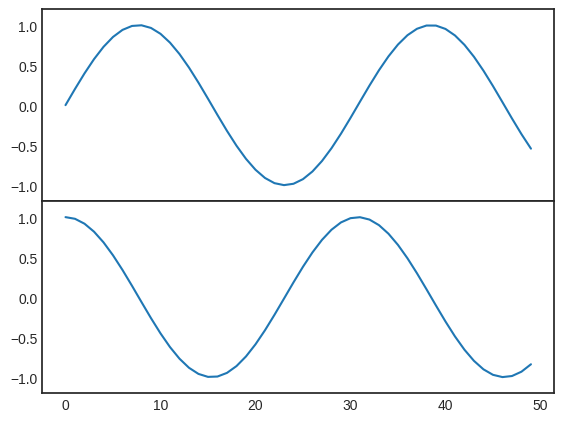

In [ ]:
#creating subplot using fig.add_axes
fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4],
                   xticklabels=[], ylim=(-1.2, 1.2))
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4],
                   ylim=(-1.2, 1.2))

x = np.linspace(0, 10)
ax1.plot(np.sin(x))
ax2.plot(np.cos(x));

### ``plt.subplot``: Simple Grids of Subplots

Aligned columns or rows of subplots are a common-enough need that Matplotlib has several convenience routines that make them easy to create.

The lowest level of these is ``plt.subplot()``, which creates a single subplot within a grid.

As you can see, this command takes three integer arguments—the number of rows, the number of columns, and the index of the plot to be created in this scheme, which runs from the upper left to the bottom right:

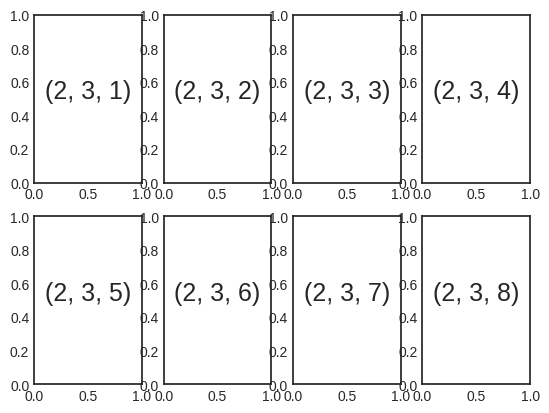

In [ ]:
for i in range(1, 9):
    plt.subplot(2, 4, i)
    plt.text(0.5, 0.5, str((2, 3, i)),
             fontsize=18, ha='center')


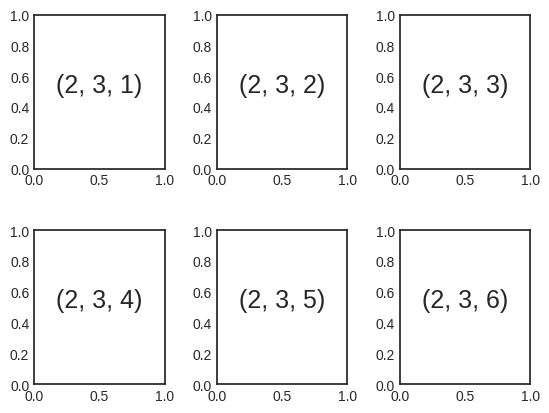

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(1, 7):
    ax = fig.add_subplot(2, 3, i)
    ax.text(0.5, 0.5, str((2, 3, i)),
           fontsize=18, ha='center')

### ``plt.subplots``: The Whole Grid in One Go

The approach just described can become quite tedious when creating a large grid of subplots, especially if you'd like to hide the x- and y-axis labels on the inner plots.
For this purpose, ``plt.subplots()`` is the easier tool to use (note the ``s`` at the end of ``subplots``). Rather than creating a single subplot, this function creates a full grid of subplots in a single line, returning them in a NumPy array.
The arguments are the number of rows and number of columns, along with optional keywords ``sharex`` and ``sharey``, which allow you to specify the relationships between different axes.

Here we'll create a $2 \times 3$ grid of subplots, where all axes in the same row share their y-axis scale, and all axes in the same column share their x-axis scale:

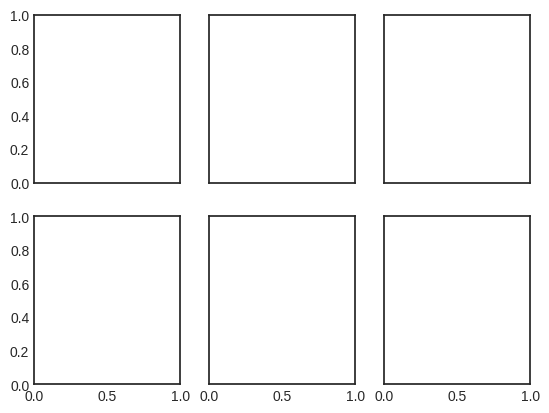

In [ ]:
fig, ax = plt.subplots(2, 3, sharex='col', sharey='row')

Note that by specifying ``sharex`` and ``sharey``, we've automatically removed inner labels on the grid to make the plot cleaner.


The resulting grid of axes instances is returned within a NumPy array, allowing for convenient specification of the desired axes using standard array indexing notation:

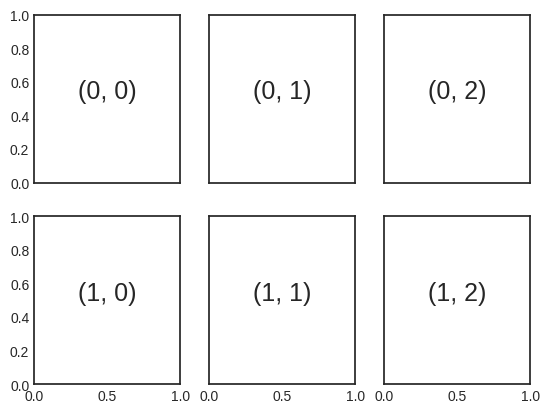

In [ ]:
# axes are in a two-dimensional array, indexed by [row, col]
for i in range(2):
    for j in range(3):
        ax[i, j].text(0.5, 0.5, str((i, j)),
                      fontsize=18, ha='center')
fig

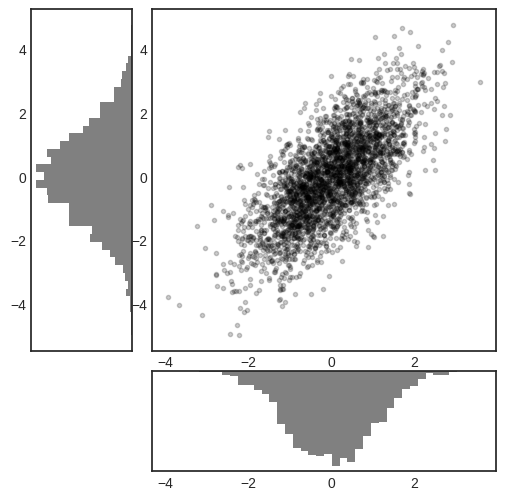

In [ ]:
# An example of Flexible grid arrangement
# Create some normally distributed data
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# Set up the axes with gridspec
fig = plt.figure(figsize=(6, 6))
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
main_ax = fig.add_subplot(grid[:-1, 1:])
y_hist = fig.add_subplot(grid[:-1, 0], xticklabels=[], sharey=main_ax)
x_hist = fig.add_subplot(grid[-1, 1:], yticklabels=[], sharex=main_ax)

# scatter points on the main axes
main_ax.plot(x, y, 'ok', markersize=3, alpha=0.2)

# histogram on the attached axes
x_hist.hist(x, 40, histtype='stepfilled',
            orientation='vertical', color='gray')
x_hist.invert_yaxis()

y_hist.hist(y, 40, histtype='stepfilled',
            orientation='horizontal', color='gray')
y_hist.invert_xaxis()


Saving births.csv to births.csv


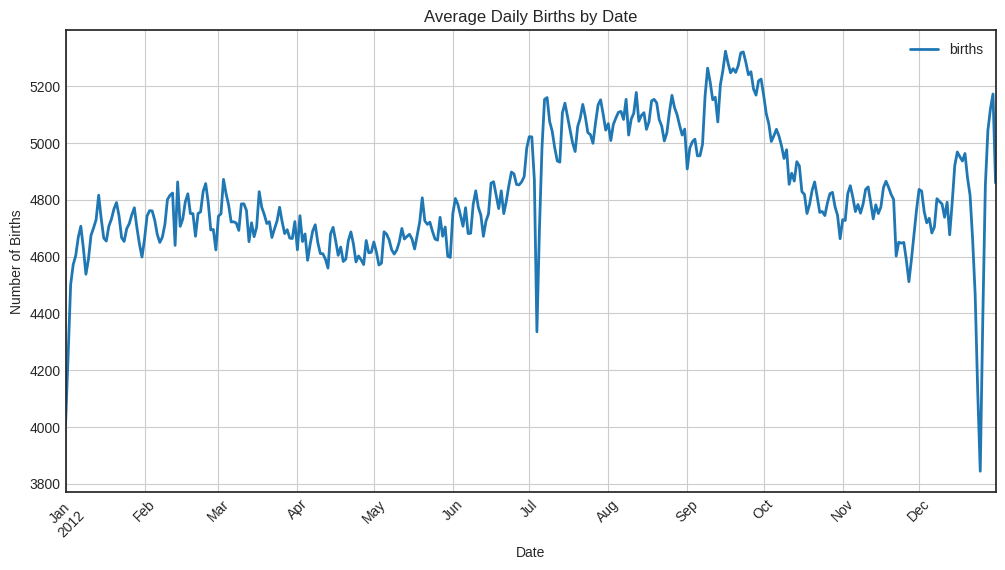

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
files.upload()

# Load dataset (make sure path is correct!)
births = pd.read_csv('births.csv')

# Clean data using quartiles
quartiles = np.percentile(births['births'], [25, 50, 75])
mu, sig = quartiles[1], 0.74 * (quartiles[2] - quartiles[0])

births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

# Fix day column
births['day'] = births['day'].astype(int)

# Create datetime index
births.index = pd.to_datetime(10000 * births.year +
                             100 * births.month +
                             births.day, format='%Y%m%d')

# Pivot table
births_by_date = births.pivot_table('births',
                                    [births.index.month, births.index.day])

# FIXED LINE HERE
births_by_date.index = [pd.Timestamp(2012, month, day)
                        for (month, day) in births_by_date.index]
# Step 8: Plot the data
fig, ax = plt.subplots(figsize=(12, 6))

births_by_date.plot(ax=ax, lw=2)

# Formatting
ax.set_title('Average Daily Births by Date')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Births')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

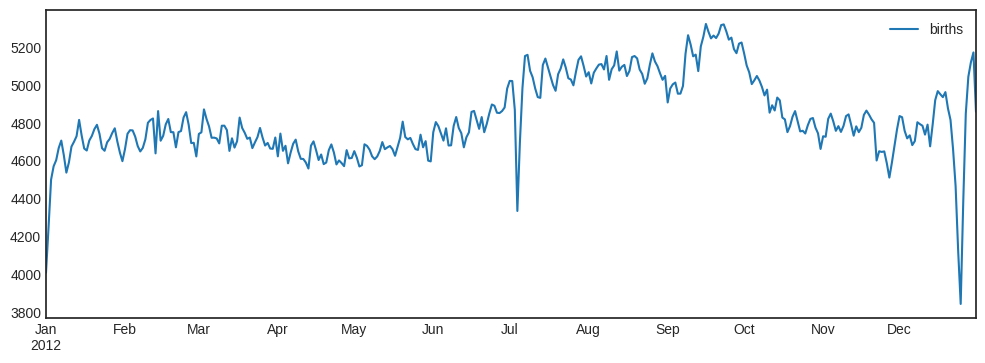

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
births_by_date.plot(ax=ax);

### Boxplot

A Box Plot is also known as Whisker plot is created to display the summary of the set of data values having properties like minimum, first quartile, median, third quartile and maximum.

In the box plot, a box is created from the first quartile to the third quartile, a vertical line is also there which goes through the box at the median. Here x-axis denotes the data to be plotted while the y-axis shows the frequency distribution.



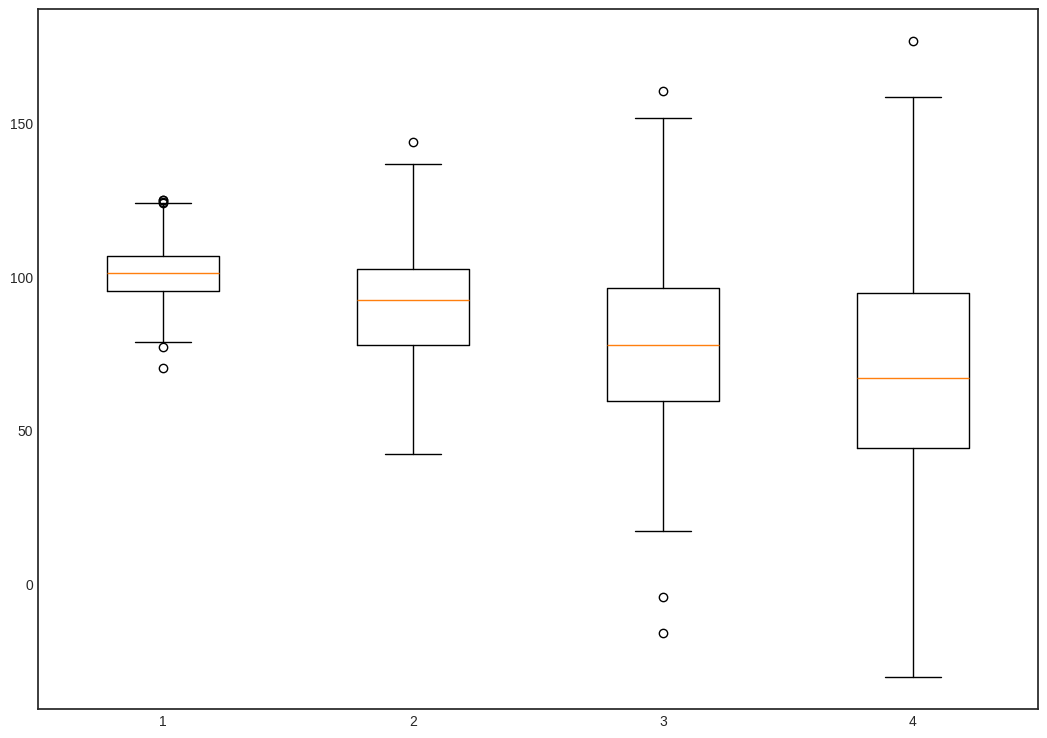

In [ ]:
#Exmple of Box plot for some random data sets
# Import libraries
import matplotlib.pyplot as plt
import numpy as np


# Creating dataset
np.random.seed(10)

data_1 = np.random.normal(100, 10, 200)
data_2 = np.random.normal(90, 20, 200)
data_3 = np.random.normal(80, 30, 200)
data_4 = np.random.normal(70, 40, 200)
data = [data_1, data_2, data_3, data_4]

fig = plt.figure(figsize =(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])

# Creating plot
bp = ax.boxplot(data)

# show plot
plt.show()


# Answers of following quetions:
###**1. What is boxplot ?**
####ans:
- A boxplot (also called a box-and-whisker plot) is a graphical representation used in statistics to summarize the distribution of a dataset. It shows how data is spread out and helps identify important characteristics like the center, variability, and outliers.

- A boxplot is a visual tool that displays the five-number summary of a dataset:

  ◾ Minimum

  ◾ First Quartile (Q1)

  ◾ Median (Q2)

  ◾ Third Quartile (Q3)

  ◾ Maximum

- Components of a Boxplot

  ◾ Box:

      Represents the range from Q1 to Q3 (called the interquartile range, IQR).
      It contains the middle 50% of the data.

  ◾ Median Line:

      A line inside the box showing the median (middle value).

  ◾ Whiskers:

      Lines extending from the box to the minimum and maximum values (excluding outliers).

  ◾ Outliers:

      Individual data points that fall far outside the normal range, usually plotted as dots.
- Purpose of a Boxplot

  ◾ To visualize data distribution

  ◾ To compare multiple datasets

  ◾ To detect outliers

  ◾ To understand skewnessPurpose of a Boxplot

    To visualize data distribution

    To compare multiple datasets

    To detect outliers

    To understand skewness

###**2. What information do we get from a box plot?**
####ANS:
A box plot (box-and-whisker plot) provides a concise summary of the distribution and characteristics of a dataset. From a box plot, we can extract the following key information:
Information obtained from a Box Plot
1. `Central Tendency (Median)`

- The line inside the box represents the median (Q2).

- It shows the middle value of the dataset and indicates where most data is centered.

2. `Spread of Data (Variability)`

- The length of the box (from Q1 to Q3) shows the interquartile range (IQR).

- It represents the spread of the middle 50% of the data.

- A larger box means greater variability.

3. `Range of Data`

- The whiskers extend from the box to the minimum and maximum values (excluding outliers).

- This shows the overall spread of the dataset.

4. `Quartiles (Data Distribution)`

- The box is divided into:

  - Q1 (First Quartile) → 25% of data below it

  - Q2 (Median) → 50% of data below it

  - Q3 (Third Quartile) → 75% of data below it

- Helps understand how data is distributed across different sections.

5. `Skewness (Symmetry of Data)`

- If the median is centered in the box → data is symmetric

- If the median is closer to Q1 or Q3 → data is skewed

  - Left skew (negative skew)

  - Right skew (positive skew)

6. `Outliers Detection`

- Points plotted outside the whiskers represent outliers

- These are extreme values that differ significantly from the rest of the data.

7. `Comparison Between Datasets`

- Multiple box plots can be compared side by side

- Helps analyze differences in:

  - Median

  - Spread

  - Variability

  - Presence of outliers

###**3. How is minimum and maximum whisker's marked in a box plot ?**
####ans:
- In a box plot, the whiskers extend from the box (Q1 and Q3) to represent the range of the data, but not always the absolute minimum and maximum.

- The lower whisker extends from Q1 (first quartile) down to the smallest data value that is within

  - Q1−1.5×IQR
  - Q1−1.5×IQR

- The upper whisker extends from Q3 (third quartile) up to the largest data value that is within

  - Q3+1.5×IQR
  - Q3+1.5×IQR

- These whiskers mark the minimum and maximum non-outlier values.

###**4. How to we identify that some points in data are outliers by viewing the box plot?**
###ans:
- Outliers are identified as individual data points that lie outside the whiskers.

- Criteria:

  Any value less than

  - Q1−1.5×IQR
  - Q1−1.5×IQR

  Any value greater than

  - Q3+1.5×IQR
  - Q3+1.5×IQR

  In the box plot:

- Outliers are shown as separate points (dots or circles) beyond the whiskers They indicate extreme or unusual values in the dataset.

###**5. Read a data file from your drive and for all numeric columns plot boxplot.**
####ans:

- to analyze numeric data using box plots, the following steps are followed:

  Step 1: Read the data file

  - A dataset is loaded from a file (such as CSV) into a data structure like a table or dataframe.

  Step 2: Identify numeric columns

  - Select columns that contain numerical values (e.g., age, salary, marks).

  Step 3: Generate box plots

  - For each numeric column, a box plot is created to visualize:

    - Median

    - Quartiles (Q1, Q3)

    - Spread (IQR)

    - Outliers

  Step 4: Analyze the plots

    - Compare distributions of different variables.

    - Detect variability and skewness.

    - Identify presence of outliers.



## Conclusion
Thus we have learned about basics of  Contour plots, Histograms, Box plots.